# 07 — Pseudo-Out-of-Sample Forecast Evaluation

This notebook evaluates whether the preferred AR(3) specification generalizes beyond its estimation sample.

Forecasts are generated using an expanding estimation window and one-step-ahead pseudo-out-of-sample evaluation. The models are compared with both naive and seasonal-naive benchmarks.

The analysis distinguishes between:

- feasible forecasts using information available before the forecast month; and
- conditional forecasts using realized contemporaneous energy-market and weather controls.

The conditional forecasts should not be interpreted as fully real-time operational forecasts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


CURRENT_DIRECTORY = Path.cwd()

if (CURRENT_DIRECTORY / "data").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY
elif (CURRENT_DIRECTORY.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root. "
        f"Current directory: {CURRENT_DIRECTORY}"
    )

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "tx_energy_economy_analysis_sample.csv"
)

FIGURE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

TABLE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The final analysis sample was not found. "
        "Run `python src/build_analysis_sample.py` first."
    )

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["period"],
)

df = (
    df
    .sort_values("period")
    .reset_index(drop=True)
)

if df["period"].duplicated().any():
    raise ValueError(
        "Duplicate monthly observations were found."
    )

expected_periods = pd.date_range(
    start=df["period"].min(),
    end=df["period"].max(),
    freq="MS",
)

missing_periods = expected_periods.difference(
    pd.DatetimeIndex(df["period"])
)

if len(missing_periods) > 0:
    raise ValueError(
        "Missing calendar months were found: "
        f"{missing_periods.strftime('%Y-%m').tolist()}"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Rows: {len(df)}")
print(
    "Date range: "
    f"{df['period'].min():%Y-%m} to "
    f"{df['period'].max():%Y-%m}"
)

Project root: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor
Rows: 136
Date range: 2015-01 to 2026-04


In [2]:
OUTCOME_VARIABLE = (
    "residential_price_real_2025_01"
)

SOURCE_VARIABLES = [
    OUTCOME_VARIABLE,
    "henry_hub_natural_gas_price",
    "natural_gas_share",
    "renewable_share",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
]

missing_columns = [
    variable
    for variable in SOURCE_VARIABLES
    if variable not in df.columns
]

if missing_columns:
    raise ValueError(
        "Required variables are missing: "
        f"{missing_columns}"
    )

forecast_df = df[
    [
        "period",
        *SOURCE_VARIABLES,
    ]
].copy()

forecast_df["time_trend"] = np.arange(
    len(forecast_df)
)

forecast_df["month_of_year"] = pd.Categorical(
    forecast_df["period"].dt.month,
    categories=range(1, 13),
    ordered=True,
)

forecast_df["natural_gas_share_pp"] = (
    100
    * forecast_df["natural_gas_share"]
)

forecast_df["renewable_share_pp"] = (
    100
    * forecast_df["renewable_share"]
)

CONTEMPORANEOUS_CONTROLS = [
    "henry_hub_natural_gas_price",
    "natural_gas_share_pp",
    "renewable_share_pp",
    "tx_heating_degree_days",
    "tx_cooling_degree_days",
]

OUTCOME_LAGS = [1, 2, 3, 12]

for lag in OUTCOME_LAGS:
    forecast_df[
        f"{OUTCOME_VARIABLE}_lag_{lag}"
    ] = (
        forecast_df[OUTCOME_VARIABLE]
        .shift(lag)
    )

LAGGED_CONTROL_VARIABLES = []

for variable in CONTEMPORANEOUS_CONTROLS:
    lagged_variable = f"{variable}_lag_1"

    forecast_df[lagged_variable] = (
        forecast_df[variable]
        .shift(1)
    )

    LAGGED_CONTROL_VARIABLES.append(
        lagged_variable
    )

REQUIRED_FORECAST_VARIABLES = [
    OUTCOME_VARIABLE,
    *[
        f"{OUTCOME_VARIABLE}_lag_{lag}"
        for lag in OUTCOME_LAGS
    ],
    *CONTEMPORANEOUS_CONTROLS,
    *LAGGED_CONTROL_VARIABLES,
    "time_trend",
    "month_of_year",
]

forecast_ready_df = (
    forecast_df
    .dropna(
        subset=REQUIRED_FORECAST_VARIABLES
    )
    .reset_index(drop=True)
)

N_TEST_OBSERVATIONS = 24

complete_blocks = (
    forecast_ready_df
    .assign(
        previous_period=lambda data: (
            data["period"].shift(1)
        ),
        expected_previous_period=lambda data: (
            data["period"]
            - pd.offsets.MonthBegin(1)
        ),
    )
)

complete_blocks["new_block"] = (
    complete_blocks["previous_period"].isna()
    | (
        complete_blocks["previous_period"]
        != complete_blocks["expected_previous_period"]
    )
)

complete_blocks["block_id"] = (
    complete_blocks["new_block"].cumsum()
)

eligible_blocks = [
    block.copy()
    for _, block in complete_blocks.groupby("block_id")
    if len(block) >= N_TEST_OBSERVATIONS
]

if not eligible_blocks:
    raise ValueError(
        "No continuous block is long enough "
        "for a 24-month test interval."
    )

selected_block = eligible_blocks[-1]

test_df = (
    selected_block
    .iloc[-N_TEST_OBSERVATIONS:]
    .drop(
        columns=[
            "previous_period",
            "expected_previous_period",
            "new_block",
            "block_id",
        ]
    )
    .copy()
)

initial_training_df = (
    forecast_ready_df.loc[
        forecast_ready_df["period"]
        < test_df["period"].min()
    ]
    .copy()
)

expected_test_periods = pd.date_range(
    start=test_df["period"].min(),
    periods=N_TEST_OBSERVATIONS,
    freq="MS",
)

if not test_df["period"].reset_index(drop=True).equals(
    pd.Series(expected_test_periods)
):
    raise ValueError(
        "The selected test interval is not continuous."
    )

print(
    "Forecast-ready observations: "
    f"{len(forecast_ready_df)}"
)

print(
    "Initial training observations: "
    f"{len(initial_training_df)}"
)

print(
    "Initial training period: "
    f"{initial_training_df['period'].min():%Y-%m} to "
    f"{initial_training_df['period'].max():%Y-%m}"
)

print(
    "Test observations: "
    f"{len(test_df)}"
)

print(
    "Continuous test period: "
    f"{test_df['period'].min():%Y-%m} to "
    f"{test_df['period'].max():%Y-%m}"
)

display(
    test_df[
        [
            "period",
            OUTCOME_VARIABLE,
            f"{OUTCOME_VARIABLE}_lag_1",
            f"{OUTCOME_VARIABLE}_lag_12",
        ]
    ]
)

Forecast-ready observations: 120
Initial training observations: 93
Initial training period: 2016-01 to 2023-09
Test observations: 24
Continuous test period: 2023-10 to 2025-09


,period,residential_price_real_2025_01,residential_price_real_2025_01_lag_1,residential_price_real_2025_01_lag_12
93,2023-10-01,15.435135,15.238247,15.990488
94,2023-11-01,15.308985,15.435135,16.023524
95,2023-12-01,15.124616,15.308985,15.466031
96,2024-01-01,14.779205,15.124616,15.246255
97,2024-02-01,14.852236,14.779205,15.575074
98,2024-03-01,15.338149,14.852236,15.439682
99,2024-04-01,15.417014,15.338149,15.124172
100,2024-05-01,15.103989,15.417014,15.404731
101,2024-06-01,14.825017,15.103989,15.055525
102,2024-07-01,14.952775,14.825017,14.607270


## Expanding-window forecast design

Five one-step-ahead forecasting specifications are evaluated over the same continuous 24-month test interval:

1. naive forecast using the previous month's realized price;
2. seasonal-naive forecast using the price from 12 months earlier;
3. an AR(3) model with deterministic trend and monthly seasonality;
4. a feasible AR(3) model using one-month-lagged controls; and
5. a conditional AR(3) model using realized contemporaneous controls.

The estimation window expands by one month after each forecast. Actual lagged outcomes are therefore available for each one-step-ahead forecast.

The feasible specification is pseudo-real-time rather than a fully vintage-based real-time forecast, because publication delays and subsequent data revisions are not modeled.

In [3]:
OUTCOME_LAG_VARIABLES = [
    f"{OUTCOME_VARIABLE}_lag_1",
    f"{OUTCOME_VARIABLE}_lag_2",
    f"{OUTCOME_VARIABLE}_lag_3",
]

DETERMINISTIC_TERMS = [
    "time_trend",
    "C(month_of_year)",
]

PRICE_ONLY_AR3_FORMULA = (
    f"{OUTCOME_VARIABLE} ~ "
    + " + ".join(
        [
            *OUTCOME_LAG_VARIABLES,
            *DETERMINISTIC_TERMS,
        ]
    )
)

FEASIBLE_AR3_FORMULA = (
    f"{OUTCOME_VARIABLE} ~ "
    + " + ".join(
        [
            *OUTCOME_LAG_VARIABLES,
            *LAGGED_CONTROL_VARIABLES,
            *DETERMINISTIC_TERMS,
        ]
    )
)

CONDITIONAL_AR3_FORMULA = (
    f"{OUTCOME_VARIABLE} ~ "
    + " + ".join(
        [
            *OUTCOME_LAG_VARIABLES,
            *CONTEMPORANEOUS_CONTROLS,
            *DETERMINISTIC_TERMS,
        ]
    )
)

REGRESSION_FORMULAS = {
    "ar3_price_history": PRICE_ONLY_AR3_FORMULA,
    "ar3_lagged_controls": FEASIBLE_AR3_FORMULA,
    "ar3_conditional_controls": CONDITIONAL_AR3_FORMULA,
}

print("Price-history AR(3):")
print(PRICE_ONLY_AR3_FORMULA)

print("\nAR(3) with lagged controls:")
print(FEASIBLE_AR3_FORMULA)

print("\nConditional AR(3):")
print(CONDITIONAL_AR3_FORMULA)

Price-history AR(3):
residential_price_real_2025_01 ~ residential_price_real_2025_01_lag_1 + residential_price_real_2025_01_lag_2 + residential_price_real_2025_01_lag_3 + time_trend + C(month_of_year)

AR(3) with lagged controls:
residential_price_real_2025_01 ~ residential_price_real_2025_01_lag_1 + residential_price_real_2025_01_lag_2 + residential_price_real_2025_01_lag_3 + henry_hub_natural_gas_price_lag_1 + natural_gas_share_pp_lag_1 + renewable_share_pp_lag_1 + tx_heating_degree_days_lag_1 + tx_cooling_degree_days_lag_1 + time_trend + C(month_of_year)

Conditional AR(3):
residential_price_real_2025_01 ~ residential_price_real_2025_01_lag_1 + residential_price_real_2025_01_lag_2 + residential_price_real_2025_01_lag_3 + henry_hub_natural_gas_price + natural_gas_share_pp + renewable_share_pp + tx_heating_degree_days + tx_cooling_degree_days + time_trend + C(month_of_year)


In [4]:
forecast_records = []

for forecast_period in test_df["period"]:
    expanding_training_df = (
        forecast_ready_df.loc[
            forecast_ready_df["period"]
            < forecast_period
        ]
        .copy()
    )

    forecast_row = (
        forecast_ready_df.loc[
            forecast_ready_df["period"]
            == forecast_period
        ]
        .copy()
    )

    if len(forecast_row) != 1:
        raise ValueError(
            "Expected exactly one forecast row for "
            f"{forecast_period:%Y-%m}, "
            f"but found {len(forecast_row)}."
        )

    if expanding_training_df.empty:
        raise ValueError(
            "The expanding training sample is empty."
        )

    if (
        expanding_training_df["period"].max()
        >= forecast_period
    ):
        raise ValueError(
            "Future information entered the "
            "training sample."
        )

    forecast_record = {
        "period": forecast_period,
        "actual": float(
            forecast_row[OUTCOME_VARIABLE].iloc[0]
        ),
        "training_start": (
            expanding_training_df["period"].min()
        ),
        "training_end": (
            expanding_training_df["period"].max()
        ),
        "n_training": len(expanding_training_df),
        "naive_previous_month": float(
            forecast_row[
                f"{OUTCOME_VARIABLE}_lag_1"
            ].iloc[0]
        ),
        "seasonal_naive": float(
            forecast_row[
                f"{OUTCOME_VARIABLE}_lag_12"
            ].iloc[0]
        ),
    }

    for model_name, formula in (
        REGRESSION_FORMULAS.items()
    ):
        fitted_model = smf.ols(
            formula=formula,
            data=expanding_training_df,
        ).fit()

        forecast_record[model_name] = float(
            fitted_model.predict(
                forecast_row
            ).iloc[0]
        )

    forecast_records.append(forecast_record)

forecast_results = pd.DataFrame(
    forecast_records
)

PREDICTION_COLUMNS = [
    "naive_previous_month",
    "seasonal_naive",
    "ar3_price_history",
    "ar3_lagged_controls",
    "ar3_conditional_controls",
]

if len(forecast_results) != N_TEST_OBSERVATIONS:
    raise ValueError(
        "The number of generated forecasts does not "
        "match the requested test length."
    )

if forecast_results[
    ["actual", *PREDICTION_COLUMNS]
].isna().any().any():
    raise ValueError(
        "Missing values were found in the "
        "forecast results."
    )

print(
    "Forecasts generated: "
    f"{len(forecast_results)}"
)

print(
    "Evaluation period: "
    f"{forecast_results['period'].min():%Y-%m} to "
    f"{forecast_results['period'].max():%Y-%m}"
)

print(
    "Training sample expands from "
    f"{forecast_results['n_training'].min()} to "
    f"{forecast_results['n_training'].max()} observations."
)

display(
    forecast_results[
        [
            "period",
            "actual",
            *PREDICTION_COLUMNS,
            "n_training",
        ]
    ]
)

Forecasts generated: 24
Evaluation period: 2023-10 to 2025-09
Training sample expands from 93 to 116 observations.


,period,actual,naive_previous_month,seasonal_naive,ar3_price_history,ar3_lagged_controls,ar3_conditional_controls,n_training
0,2023-10-01,15.435135,15.238247,15.990488,15.192032,14.945923,15.047135,93
1,2023-11-01,15.308985,15.435135,16.023524,15.449372,15.278399,15.387122,94
2,2023-12-01,15.124616,15.308985,15.466031,14.903154,14.862866,14.801929,95
3,2024-01-01,14.779205,15.124616,15.246255,14.867354,14.756257,14.968437,96
4,2024-02-01,14.852236,14.779205,15.575074,15.232687,15.147681,14.876649,97
5,2024-03-01,15.338149,14.852236,15.439682,15.041226,15.017570,14.971862,98
6,2024-04-01,15.417014,15.338149,15.124172,15.343895,15.170095,15.097104,99
7,2024-05-01,15.103989,15.417014,15.404731,15.309709,15.095966,15.174690,100
8,2024-06-01,14.825017,15.103989,15.055525,15.066292,15.027221,14.951430,101
9,2024-07-01,14.952775,14.825017,14.607270,14.748593,14.679342,14.632636,102


## Forecast accuracy comparison

Forecast performance is evaluated using:

- RMSE, which penalizes relatively large forecast errors;
- MAE, which measures the average absolute forecast error; and
- mean error, defined as actual minus forecast, which measures directional bias.

Positive mean error indicates systematic underprediction, while negative mean error indicates systematic overprediction.

Percentage improvements are calculated relative to the previous-month naive benchmark. Positive values indicate better performance than the benchmark.

In [5]:
MODEL_LABELS = {
    "naive_previous_month": "Previous-month naive",
    "seasonal_naive": "Seasonal naive",
    "ar3_price_history": "AR(3): price history",
    "ar3_lagged_controls": "AR(3): lagged controls",
    "ar3_conditional_controls": (
        "AR(3): conditional controls"
    ),
}

forecast_metric_records = []

for model_name in PREDICTION_COLUMNS:
    forecast_errors = (
        forecast_results["actual"]
        - forecast_results[model_name]
    )

    forecast_metric_records.append(
        {
            "model": model_name,
            "model_label": MODEL_LABELS[model_name],
            "rmse": np.sqrt(
                np.mean(forecast_errors ** 2)
            ),
            "mae": np.mean(
                np.abs(forecast_errors)
            ),
            "mean_error": np.mean(
                forecast_errors
            ),
            "maximum_absolute_error": np.max(
                np.abs(forecast_errors)
            ),
        }
    )

forecast_metrics = pd.DataFrame(
    forecast_metric_records
)

naive_metrics = (
    forecast_metrics
    .set_index("model")
    .loc["naive_previous_month"]
)

forecast_metrics[
    "rmse_improvement_vs_naive_pct"
] = (
    100
    * (
        naive_metrics["rmse"]
        - forecast_metrics["rmse"]
    )
    / naive_metrics["rmse"]
)

forecast_metrics[
    "mae_improvement_vs_naive_pct"
] = (
    100
    * (
        naive_metrics["mae"]
        - forecast_metrics["mae"]
    )
    / naive_metrics["mae"]
)

forecast_metrics["rmse_rank"] = (
    forecast_metrics["rmse"]
    .rank(
        method="min",
        ascending=True,
    )
    .astype(int)
)

forecast_metrics = (
    forecast_metrics
    .sort_values(
        ["rmse", "mae"]
    )
    .reset_index(drop=True)
)

display(
    forecast_metrics[
        [
            "model_label",
            "rmse",
            "mae",
            "mean_error",
            "maximum_absolute_error",
            "rmse_improvement_vs_naive_pct",
            "mae_improvement_vs_naive_pct",
            "rmse_rank",
        ]
    ]
    .style
    .format(
        {
            "rmse": "{:.4f}",
            "mae": "{:.4f}",
            "mean_error": "{:.4f}",
            "maximum_absolute_error": "{:.4f}",
            "rmse_improvement_vs_naive_pct": "{:.2f}%",
            "mae_improvement_vs_naive_pct": "{:.2f}%",
        }
    )
)

,model_label,rmse,mae,mean_error,maximum_absolute_error,rmse_improvement_vs_naive_pct,mae_improvement_vs_naive_pct,rmse_rank
0,AR(3): price history,0.2380,0.1969,0.0145,0.5356,20.87%,18.33%,1
1,AR(3): lagged controls,0.2825,0.2270,0.0912,0.6774,6.07%,5.81%,2
2,Previous-month naive,0.3008,0.2411,0.0139,0.7556,0.00%,0.00%,3
3,AR(3): conditional controls,0.3024,0.2459,0.0973,0.6497,-0.54%,-2.01%,4
4,Seasonal naive,0.3577,0.3022,-0.0016,0.7228,-18.93%,-25.38%,5


In [6]:
FORECAST_RESULTS_PATH = (
    TABLE_DIRECTORY
    / "out_of_sample_forecasts.csv"
)

FORECAST_METRICS_PATH = (
    TABLE_DIRECTORY
    / "out_of_sample_forecast_metrics.csv"
)

forecast_results.to_csv(
    FORECAST_RESULTS_PATH,
    index=False,
)

forecast_metrics.to_csv(
    FORECAST_METRICS_PATH,
    index=False,
)

print(
    f"Saved forecast results to: "
    f"{FORECAST_RESULTS_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    f"Saved forecast metrics to: "
    f"{FORECAST_METRICS_PATH.relative_to(PROJECT_ROOT)}"
)

Saved forecast results to: reports\tables\out_of_sample_forecasts.csv
Saved forecast metrics to: reports\tables\out_of_sample_forecast_metrics.csv


## Monthly forecast errors and stability

Aggregate accuracy measures may conceal substantial variation across months. This section examines how often each model outperforms the previous-month naive benchmark and whether the preferred AR(3) result is driven by one or two unusually influential forecast months.

A positive absolute-error gain or squared-error gain indicates that the evaluated model outperformed the previous-month naive forecast in that month.

In [7]:
forecast_error_details = forecast_results[
    [
        "period",
        "actual",
        *PREDICTION_COLUMNS,
    ]
].copy()

for model_name in PREDICTION_COLUMNS:
    forecast_error_details[
        f"{model_name}_error"
    ] = (
        forecast_error_details["actual"]
        - forecast_error_details[model_name]
    )

    forecast_error_details[
        f"{model_name}_absolute_error"
    ] = (
        forecast_error_details[
            f"{model_name}_error"
        ].abs()
    )

    forecast_error_details[
        f"{model_name}_squared_error"
    ] = (
        forecast_error_details[
            f"{model_name}_error"
        ] ** 2
    )

NAIVE_MODEL = "naive_previous_month"

COMPARISON_MODELS = [
    model_name
    for model_name in PREDICTION_COLUMNS
    if model_name != NAIVE_MODEL
]

monthly_win_records = []

for model_name in COMPARISON_MODELS:
    absolute_error_gain = (
        forecast_error_details[
            f"{NAIVE_MODEL}_absolute_error"
        ]
        - forecast_error_details[
            f"{model_name}_absolute_error"
        ]
    )

    squared_error_gain = (
        forecast_error_details[
            f"{NAIVE_MODEL}_squared_error"
        ]
        - forecast_error_details[
            f"{model_name}_squared_error"
        ]
    )

    ties = np.isclose(
        absolute_error_gain,
        0.0,
    )

    monthly_win_records.append(
        {
            "model": model_name,
            "model_label": MODEL_LABELS[model_name],
            "months_better_than_naive": int(
                (absolute_error_gain > 0).sum()
            ),
            "months_worse_than_naive": int(
                (absolute_error_gain < 0).sum()
            ),
            "months_tied_with_naive": int(
                ties.sum()
            ),
            "mean_absolute_error_gain": (
                absolute_error_gain.mean()
            ),
            "median_absolute_error_gain": (
                absolute_error_gain.median()
            ),
            "total_squared_error_gain": (
                squared_error_gain.sum()
            ),
        }
    )

monthly_win_summary = pd.DataFrame(
    monthly_win_records
)

display(
    monthly_win_summary[
        [
            "model_label",
            "months_better_than_naive",
            "months_worse_than_naive",
            "months_tied_with_naive",
            "mean_absolute_error_gain",
            "median_absolute_error_gain",
            "total_squared_error_gain",
        ]
    ]
    .style
    .format(
        {
            "mean_absolute_error_gain": "{:.4f}",
            "median_absolute_error_gain": "{:.4f}",
            "total_squared_error_gain": "{:.4f}",
        }
    )
)

,model_label,months_better_than_naive,months_worse_than_naive,months_tied_with_naive,mean_absolute_error_gain,median_absolute_error_gain,total_squared_error_gain
0,Seasonal naive,11,13,0,-0.0612,-0.0527,-0.8998
1,AR(3): price history,15,9,0,0.0442,0.0352,0.8120
2,AR(3): lagged controls,13,11,0,0.0140,0.0421,0.2557
3,AR(3): conditional controls,13,11,0,-0.0049,0.0438,-0.0235


In [8]:
PREFERRED_FORECAST_MODEL = "ar3_price_history"

preferred_month_details = forecast_error_details[
    [
        "period",
        "actual",
        NAIVE_MODEL,
        PREFERRED_FORECAST_MODEL,
        f"{NAIVE_MODEL}_absolute_error",
        f"{PREFERRED_FORECAST_MODEL}_absolute_error",
        f"{NAIVE_MODEL}_squared_error",
        f"{PREFERRED_FORECAST_MODEL}_squared_error",
    ]
].copy()

preferred_month_details[
    "absolute_error_gain_vs_naive"
] = (
    preferred_month_details[
        f"{NAIVE_MODEL}_absolute_error"
    ]
    - preferred_month_details[
        f"{PREFERRED_FORECAST_MODEL}_absolute_error"
    ]
)

preferred_month_details[
    "squared_error_gain_vs_naive"
] = (
    preferred_month_details[
        f"{NAIVE_MODEL}_squared_error"
    ]
    - preferred_month_details[
        f"{PREFERRED_FORECAST_MODEL}_squared_error"
    ]
)

preferred_month_details[
    "gain_magnitude"
] = preferred_month_details[
    "squared_error_gain_vs_naive"
].abs()

largest_monthly_differences = (
    preferred_month_details
    .sort_values(
        "gain_magnitude",
        ascending=False,
    )
    .head(10)
    .drop(columns="gain_magnitude")
)

display(
    largest_monthly_differences
    .style
    .format(
        {
            "actual": "{:.4f}",
            NAIVE_MODEL: "{:.4f}",
            PREFERRED_FORECAST_MODEL: "{:.4f}",
            f"{NAIVE_MODEL}_absolute_error": "{:.4f}",
            f"{PREFERRED_FORECAST_MODEL}_absolute_error": "{:.4f}",
            f"{NAIVE_MODEL}_squared_error": "{:.4f}",
            f"{PREFERRED_FORECAST_MODEL}_squared_error": "{:.4f}",
            "absolute_error_gain_vs_naive": "{:.4f}",
            "squared_error_gain_vs_naive": "{:.4f}",
        }
    )
)

,period,actual,naive_previous_month,ar3_price_history,naive_previous_month_absolute_error,ar3_price_history_absolute_error,naive_previous_month_squared_error,ar3_price_history_squared_error,absolute_error_gain_vs_naive,squared_error_gain_vs_naive
15,2025-01-01 00:00:00,14.6700,15.4256,15.2056,0.7556,0.5356,0.5710,0.2869,0.2200,0.2841
16,2025-02-01 00:00:00,14.8466,14.6700,15.2831,0.1766,0.4365,0.0312,0.1906,-0.2599,-0.1594
5,2024-03-01 00:00:00,15.3381,14.8522,15.0412,0.4859,0.2969,0.2361,0.0882,0.1890,0.1479
4,2024-02-01 00:00:00,14.8522,14.7792,15.2327,0.0730,0.3805,0.0053,0.1447,-0.3074,-0.1394
17,2025-03-01 00:00:00,15.2406,14.8466,15.1032,0.3940,0.1375,0.1553,0.0189,0.2566,0.1364
14,2024-12-01 00:00:00,15.4256,15.8005,15.2841,0.3749,0.1415,0.1405,0.0200,0.2334,0.1205
12,2024-10-01 00:00:00,15.8353,15.2624,15.3756,0.5730,0.4597,0.3283,0.2113,0.1133,0.1170
3,2024-01-01 00:00:00,14.7792,15.1246,14.8674,0.3454,0.0881,0.1193,0.0078,0.2573,0.1115
23,2025-09-01 00:00:00,15.5720,15.2529,15.5114,0.3191,0.0606,0.1018,0.0037,0.2585,0.0981
20,2025-06-01 00:00:00,15.1425,15.4496,15.2246,0.3071,0.0820,0.0943,0.0067,0.2251,0.0876


In [9]:
leave_one_month_out_records = []

for model_name in COMPARISON_MODELS:
    for omitted_index, omitted_row in (
        forecast_error_details.iterrows()
    ):
        remaining_forecasts = (
            forecast_error_details
            .drop(index=omitted_index)
        )

        naive_errors = (
            remaining_forecasts["actual"]
            - remaining_forecasts[NAIVE_MODEL]
        )

        model_errors = (
            remaining_forecasts["actual"]
            - remaining_forecasts[model_name]
        )

        naive_rmse = np.sqrt(
            np.mean(naive_errors ** 2)
        )

        model_rmse = np.sqrt(
            np.mean(model_errors ** 2)
        )

        naive_mae = np.mean(
            np.abs(naive_errors)
        )

        model_mae = np.mean(
            np.abs(model_errors)
        )

        leave_one_month_out_records.append(
            {
                "model": model_name,
                "model_label": MODEL_LABELS[model_name],
                "omitted_period": omitted_row["period"],
                "rmse_improvement_vs_naive_pct": (
                    100
                    * (naive_rmse - model_rmse)
                    / naive_rmse
                ),
                "mae_improvement_vs_naive_pct": (
                    100
                    * (naive_mae - model_mae)
                    / naive_mae
                ),
            }
        )

leave_one_month_out_results = pd.DataFrame(
    leave_one_month_out_records
)

leave_one_month_out_summary = (
    leave_one_month_out_results
    .groupby(
        [
            "model",
            "model_label",
        ],
        as_index=False,
    )
    .agg(
        minimum_rmse_improvement_pct=(
            "rmse_improvement_vs_naive_pct",
            "min",
        ),
        maximum_rmse_improvement_pct=(
            "rmse_improvement_vs_naive_pct",
            "max",
        ),
        minimum_mae_improvement_pct=(
            "mae_improvement_vs_naive_pct",
            "min",
        ),
        maximum_mae_improvement_pct=(
            "mae_improvement_vs_naive_pct",
            "max",
        ),
    )
)

display(
    leave_one_month_out_summary[
        [
            "model_label",
            "minimum_rmse_improvement_pct",
            "maximum_rmse_improvement_pct",
            "minimum_mae_improvement_pct",
            "maximum_mae_improvement_pct",
        ]
    ]
    .style
    .format(
        {
            "minimum_rmse_improvement_pct": "{:.2f}%",
            "maximum_rmse_improvement_pct": "{:.2f}%",
            "minimum_mae_improvement_pct": "{:.2f}%",
            "maximum_mae_improvement_pct": "{:.2f}%",
        }
    )
)

,model_label,minimum_rmse_improvement_pct,maximum_rmse_improvement_pct,minimum_mae_improvement_pct,maximum_mae_improvement_pct
0,AR(3): conditional controls,-5.25%,8.81%,-7.66%,6.26%
1,AR(3): lagged controls,2.52%,11.34%,-0.90%,11.25%
2,AR(3): price history,18.13%,26.10%,14.67%,23.94%
3,Seasonal naive,-38.25%,-8.47%,-42.04%,-14.33%


## Interpretation of forecast stability

The price-history AR(3) is the most consistently successful forecasting specification. It produced a smaller absolute error than the previous-month naive benchmark in 15 of the 24 evaluation months. Both its mean and median absolute-error gains were positive, while its cumulative squared-error gain was also substantially positive.

The result is not driven by a single unusually favorable month. When each evaluation month is omitted in turn, the price-history AR(3) continues to improve RMSE by between 18.13% and 26.10% and MAE by between 14.67% and 23.94% relative to the naive benchmark.

The AR(3) with lagged controls provides a smaller and less uniform improvement. Its RMSE advantage remains positive under the leave-one-month-out checks, but its MAE advantage can disappear after removing an individual month.

The conditional-control model frequently produces small improvements but occasionally incurs relatively large forecast losses. Consequently, its median absolute-error gain is positive even though its mean absolute-error gain and total squared-error gain are negative.

These results favor a parsimonious price-history specification for forecasting. They do not invalidate the explanatory AR(3) model used in the preceding notebook: variables that help characterize conditional economic relationships do not necessarily improve out-of-sample prediction.

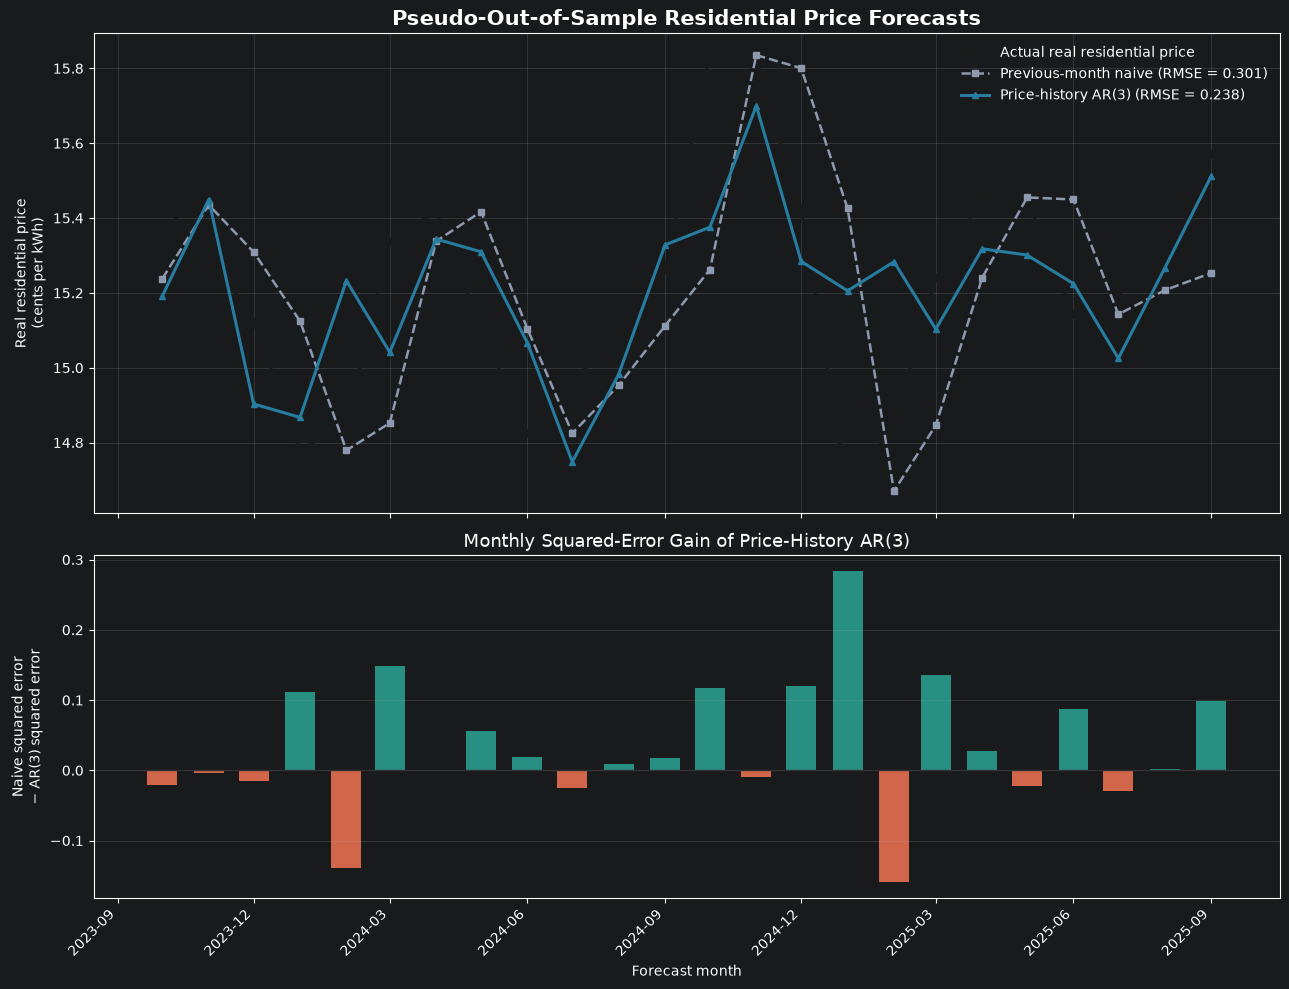

Saved forecast figure to: reports\figures\out_of_sample_forecast_performance.png


In [10]:
import matplotlib.dates as mdates


metric_lookup = (
    forecast_metrics
    .set_index("model")
)

gain_plot_df = (
    preferred_month_details
    .sort_values("period")
    .reset_index(drop=True)
)

gain_colors = np.where(
    gain_plot_df["squared_error_gain_vs_naive"] >= 0,
    "#2a9d8f",
    "#e76f51",
)

figure, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 10),
    sharex=True,
    gridspec_kw={
        "height_ratios": [1.4, 1],
    },
)

forecast_axis = axes[0]

forecast_axis.plot(
    forecast_results["period"],
    forecast_results["actual"],
    color="#1a1a1a",
    linewidth=2.5,
    marker="o",
    markersize=5,
    label="Actual real residential price",
)

forecast_axis.plot(
    forecast_results["period"],
    forecast_results[NAIVE_MODEL],
    color="#8d99ae",
    linewidth=1.8,
    linestyle="--",
    marker="s",
    markersize=4,
    label=(
        "Previous-month naive "
        f"(RMSE = "
        f"{metric_lookup.loc[NAIVE_MODEL, 'rmse']:.3f})"
    ),
)

forecast_axis.plot(
    forecast_results["period"],
    forecast_results[PREFERRED_FORECAST_MODEL],
    color="#277da1",
    linewidth=2.2,
    marker="^",
    markersize=5,
    label=(
        "Price-history AR(3) "
        f"(RMSE = "
        f"{metric_lookup.loc[PREFERRED_FORECAST_MODEL, 'rmse']:.3f})"
    ),
)

forecast_axis.set_title(
    "Pseudo-Out-of-Sample Residential Price Forecasts",
    fontsize=15,
    weight="bold",
)

forecast_axis.set_ylabel(
    "Real residential price\n(cents per kWh)",
)

forecast_axis.legend(
    frameon=False,
    loc="best",
)

forecast_axis.grid(
    alpha=0.25,
)

gain_axis = axes[1]

gain_axis.bar(
    gain_plot_df["period"],
    gain_plot_df["squared_error_gain_vs_naive"],
    width=20,
    color=gain_colors,
    alpha=0.9,
)

gain_axis.axhline(
    0,
    color="#333333",
    linewidth=1,
)

gain_axis.set_title(
    "Monthly Squared-Error Gain of Price-History AR(3)",
    fontsize=13,
)

gain_axis.set_ylabel(
    "Naive squared error\n− AR(3) squared error",
)

gain_axis.set_xlabel(
    "Forecast month",
)

gain_axis.grid(
    axis="y",
    alpha=0.25,
)

gain_axis.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

gain_axis.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.setp(
    gain_axis.get_xticklabels(),
    rotation=45,
    ha="right",
)

figure.tight_layout()

FORECAST_FIGURE_PATH = (
    FIGURE_DIRECTORY
    / "out_of_sample_forecast_performance.png"
)

figure.savefig(
    FORECAST_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved forecast figure to: "
    f"{FORECAST_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

In [11]:
MONTHLY_WIN_SUMMARY_PATH = (
    TABLE_DIRECTORY
    / "forecast_monthly_win_summary.csv"
)

MONTHLY_DETAILS_PATH = (
    TABLE_DIRECTORY
    / "preferred_forecast_monthly_details.csv"
)

LEAVE_ONE_OUT_RESULTS_PATH = (
    TABLE_DIRECTORY
    / "forecast_leave_one_month_out_results.csv"
)

LEAVE_ONE_OUT_SUMMARY_PATH = (
    TABLE_DIRECTORY
    / "forecast_leave_one_month_out_summary.csv"
)

monthly_win_summary.to_csv(
    MONTHLY_WIN_SUMMARY_PATH,
    index=False,
)

preferred_month_details.drop(
    columns="gain_magnitude",
    errors="ignore",
).to_csv(
    MONTHLY_DETAILS_PATH,
    index=False,
)

leave_one_month_out_results.to_csv(
    LEAVE_ONE_OUT_RESULTS_PATH,
    index=False,
)

leave_one_month_out_summary.to_csv(
    LEAVE_ONE_OUT_SUMMARY_PATH,
    index=False,
)

for output_path in [
    MONTHLY_WIN_SUMMARY_PATH,
    MONTHLY_DETAILS_PATH,
    LEAVE_ONE_OUT_RESULTS_PATH,
    LEAVE_ONE_OUT_SUMMARY_PATH,
]:
    print(
        f"Saved: {output_path.relative_to(PROJECT_ROOT)}"
    )

Saved: reports\tables\forecast_monthly_win_summary.csv
Saved: reports\tables\preferred_forecast_monthly_details.csv
Saved: reports\tables\forecast_leave_one_month_out_results.csv
Saved: reports\tables\forecast_leave_one_month_out_summary.csv


## Statistical comparison of forecast accuracy

Descriptive accuracy improvements do not necessarily imply statistically distinguishable predictive performance. The preferred price-history AR(3) is therefore compared with the previous-month naive benchmark using:

- Harvey–Leybourne–Newbold corrected Diebold–Mariano tests under squared and absolute loss;
- a Clark–West adjusted test under squared loss, which accounts for the fact that the naive benchmark is nested within the larger AR(3) specification; and
- an exact sign test based on the number of months in which the AR(3) produced a smaller absolute error.

Positive loss differentials indicate that the price-history AR(3) outperformed the naive benchmark. Because the evaluation sample contains only 24 months and the preferred model was identified after comparing several specifications, the statistical results should be interpreted as supportive rather than definitive confirmatory evidence.

In [12]:
from scipy import stats


def diebold_mariano_test(
    benchmark_errors,
    candidate_errors,
    loss="squared",
    horizon=1,
):
    benchmark_errors = np.asarray(
        benchmark_errors,
        dtype=float,
    )

    candidate_errors = np.asarray(
        candidate_errors,
        dtype=float,
    )

    if len(benchmark_errors) != len(candidate_errors):
        raise ValueError(
            "The two error series must have equal length."
        )

    if loss == "squared":
        benchmark_loss = benchmark_errors ** 2
        candidate_loss = candidate_errors ** 2
    elif loss == "absolute":
        benchmark_loss = np.abs(benchmark_errors)
        candidate_loss = np.abs(candidate_errors)
    else:
        raise ValueError(
            "Loss must be either 'squared' or 'absolute'."
        )

    loss_difference = (
        benchmark_loss
        - candidate_loss
    )

    n_observations = len(loss_difference)

    if not 1 <= horizon <= n_observations:
        raise ValueError(
            "The forecast horizon is invalid."
        )

    centered_difference = (
        loss_difference
        - loss_difference.mean()
    )

    autocovariances = []

    for lag in range(horizon):
        if lag == 0:
            autocovariance = np.dot(
                centered_difference,
                centered_difference,
            ) / n_observations
        else:
            autocovariance = np.dot(
                centered_difference[lag:],
                centered_difference[:-lag],
            ) / n_observations

        autocovariances.append(autocovariance)

    long_run_variance = (
        autocovariances[0]
        + 2 * sum(autocovariances[1:])
    )

    if long_run_variance <= 0:
        raise ValueError(
            "The estimated long-run variance "
            "is not positive."
        )

    raw_statistic = (
        loss_difference.mean()
        / np.sqrt(
            long_run_variance
            / n_observations
        )
    )

    hln_correction = np.sqrt(
        (
            n_observations
            + 1
            - 2 * horizon
            + (
                horizon
                * (horizon - 1)
                / n_observations
            )
        )
        / n_observations
    )

    corrected_statistic = (
        raw_statistic
        * hln_correction
    )

    degrees_of_freedom = (
        n_observations - 1
    )

    return {
        "mean_loss_gain": loss_difference.mean(),
        "statistic": corrected_statistic,
        "p_value_two_sided": (
            2
            * stats.t.sf(
                abs(corrected_statistic),
                df=degrees_of_freedom,
            )
        ),
        "p_value_one_sided_better": (
            stats.t.sf(
                corrected_statistic,
                df=degrees_of_freedom,
            )
        ),
    }


def clark_west_test(
    actual,
    benchmark_forecast,
    candidate_forecast,
):
    actual = np.asarray(actual, dtype=float)
    benchmark_forecast = np.asarray(
        benchmark_forecast,
        dtype=float,
    )
    candidate_forecast = np.asarray(
        candidate_forecast,
        dtype=float,
    )

    benchmark_errors = (
        actual - benchmark_forecast
    )

    candidate_errors = (
        actual - candidate_forecast
    )

    adjusted_loss_difference = (
        benchmark_errors ** 2
        - (
            candidate_errors ** 2
            - (
                benchmark_forecast
                - candidate_forecast
            ) ** 2
        )
    )

    n_observations = len(
        adjusted_loss_difference
    )

    standard_error = (
        adjusted_loss_difference.std(ddof=1)
        / np.sqrt(n_observations)
    )

    statistic = (
        adjusted_loss_difference.mean()
        / standard_error
    )

    return {
        "mean_adjusted_loss_gain": (
            adjusted_loss_difference.mean()
        ),
        "statistic": statistic,
        "p_value_one_sided_better": (
            stats.t.sf(
                statistic,
                df=n_observations - 1,
            )
        ),
    }

In [13]:
benchmark_errors = (
    forecast_results["actual"]
    - forecast_results[NAIVE_MODEL]
)

preferred_errors = (
    forecast_results["actual"]
    - forecast_results[
        PREFERRED_FORECAST_MODEL
    ]
)

dm_squared_result = diebold_mariano_test(
    benchmark_errors=benchmark_errors,
    candidate_errors=preferred_errors,
    loss="squared",
    horizon=1,
)

dm_absolute_result = diebold_mariano_test(
    benchmark_errors=benchmark_errors,
    candidate_errors=preferred_errors,
    loss="absolute",
    horizon=1,
)

clark_west_result = clark_west_test(
    actual=forecast_results["actual"],
    benchmark_forecast=(
        forecast_results[NAIVE_MODEL]
    ),
    candidate_forecast=(
        forecast_results[
            PREFERRED_FORECAST_MODEL
        ]
    ),
)

absolute_error_gain = (
    np.abs(benchmark_errors)
    - np.abs(preferred_errors)
)

months_better = int(
    (absolute_error_gain > 0).sum()
)

months_worse = int(
    (absolute_error_gain < 0).sum()
)

non_tied_months = (
    months_better + months_worse
)

sign_test_result = stats.binomtest(
    k=months_better,
    n=non_tied_months,
    p=0.5,
    alternative="greater",
)

forecast_statistical_tests = pd.DataFrame(
    [
        {
            "test": (
                "DM, squared loss "
                "(HLN corrected)"
            ),
            "mean_gain": (
                dm_squared_result[
                    "mean_loss_gain"
                ]
            ),
            "statistic": (
                dm_squared_result["statistic"]
            ),
            "p_value_two_sided": (
                dm_squared_result[
                    "p_value_two_sided"
                ]
            ),
            "p_value_one_sided_better": (
                dm_squared_result[
                    "p_value_one_sided_better"
                ]
            ),
        },
        {
            "test": (
                "DM, absolute loss "
                "(HLN corrected)"
            ),
            "mean_gain": (
                dm_absolute_result[
                    "mean_loss_gain"
                ]
            ),
            "statistic": (
                dm_absolute_result["statistic"]
            ),
            "p_value_two_sided": (
                dm_absolute_result[
                    "p_value_two_sided"
                ]
            ),
            "p_value_one_sided_better": (
                dm_absolute_result[
                    "p_value_one_sided_better"
                ]
            ),
        },
        {
            "test": (
                "Clark-West, adjusted squared loss"
            ),
            "mean_gain": (
                clark_west_result[
                    "mean_adjusted_loss_gain"
                ]
            ),
            "statistic": (
                clark_west_result["statistic"]
            ),
            "p_value_two_sided": np.nan,
            "p_value_one_sided_better": (
                clark_west_result[
                    "p_value_one_sided_better"
                ]
            ),
        },
        {
            "test": (
                "Exact sign test, absolute errors"
            ),
            "mean_gain": (
                months_better
                / non_tied_months
            ),
            "statistic": months_better,
            "p_value_two_sided": np.nan,
            "p_value_one_sided_better": (
                sign_test_result.pvalue
            ),
        },
    ]
)

display(
    forecast_statistical_tests
    .style
    .format(
        {
            "mean_gain": "{:.4f}",
            "statistic": "{:.4f}",
            "p_value_two_sided": "{:.4f}",
            "p_value_one_sided_better": "{:.4f}",
        },
        na_rep="—",
    )
)

,test,mean_gain,statistic,p_value_two_sided,p_value_one_sided_better
0,"DM, squared loss (HLN corrected)",0.0338,1.7606,0.0916,0.0458
1,"DM, absolute loss (HLN corrected)",0.0442,1.3485,0.1906,0.0953
2,"Clark-West, adjusted squared loss",0.0961,4.1655,—,0.0002
3,"Exact sign test, absolute errors",0.6250,15.0000,—,0.1537


In [14]:
STATISTICAL_TESTS_PATH = (
    TABLE_DIRECTORY
    / "forecast_statistical_tests.csv"
)

forecast_statistical_tests.to_csv(
    STATISTICAL_TESTS_PATH,
    index=False,
)

print(
    "Saved forecast statistical tests to: "
    f"{STATISTICAL_TESTS_PATH.relative_to(PROJECT_ROOT)}"
)

Saved forecast statistical tests to: reports\tables\forecast_statistical_tests.csv


## Conclusion

This notebook evaluated five one-step-ahead forecasting specifications over a continuous 24-month pseudo-out-of-sample period from October 2023 through September 2025. Each regression model was re-estimated using an expanding window, ensuring that only observations preceding the forecast month entered the estimation sample.

The price-history AR(3) produced the strongest overall forecasting performance. Its RMSE was 0.2380, compared with 0.3008 for the previous-month naive benchmark, representing a 20.87% improvement. Its MAE declined from 0.2411 to 0.1969, an improvement of approximately 18.33%. The model outperformed the naive benchmark in 15 of the 24 evaluation months.

The result is not attributable to a single unusually favorable forecast month. After omitting each month in turn, the price-history AR(3) continued to improve RMSE by between 18.13% and 26.10% and MAE by between 14.67% and 23.94% relative to the naive benchmark.

The statistical evidence is supportive but mixed. The two-sided Diebold–Mariano tests do not reject equal predictive accuracy at the 5% level, although the squared-loss test is significant under a one-sided directional alternative. The Clark–West test, which is more appropriate for comparing the larger AR(3) specification with the nested naive benchmark, provides strong evidence of incremental predictive information. In contrast, the exact sign test is not significant, suggesting that the AR(3)'s advantage is reflected more in the magnitude of its error reductions than in an overwhelming number of monthly wins.

Adding economic controls did not improve forecast accuracy. The specification with lagged controls produced only a modest improvement, while the conditional-control model performed slightly worse than the naive benchmark on aggregate. This does not contradict the explanatory results of the preceding notebook: variables that help characterize conditional economic relationships do not necessarily provide additional short-run forecasting information.

Overall, the results favor a parsimonious price-history AR(3) for short-term forecasting of Texas real residential electricity prices. Nevertheless, the evaluation sample is limited to 24 months, the preferred model was selected after comparing several alternatives, and the pseudo-real-time design does not incorporate publication delays or historical data vintages. The findings should therefore be interpreted as promising forecasting evidence rather than definitive model superiority.